<center><h1> Four-Eloop </h1></center>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from MCA_lib import *
import pennylane as qml

## Variables Input

In [3]:
# Número de símbolos que deseas crear
num_ext_edges=4
num_int_edges=4
num_edges =num_ext_edges+num_int_edges

num_no_reverse_clauses = 13

num_propagator_edge = 2

needs_extra_qubit = True

name_diagram = '4E16'

num_shots = 5000000

cut=100

## Logical Variables

In [4]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [5]:
# Definir auxiliares 

######################## Loops - 3 propagators ######################

c[0] = And(S[0],S[5], Sp[4])
          
c[1] = And(S[1], S[6], Sp[5]) #13

c[2] = And(S[2], S[7], Sp[6]) #14

c[3] = And(S[3],S[4], Sp[7]) #15
       
######################## Loops - 4 propagators ######################

c[4] = And(S[0], S[1], S[6], Sp[4])
       
c[5] = And(S[1], S[2], S[7], Sp[5]) #16

c[6] = And(S[2], S[3], S[4], Sp[6]) #17
          
c[7] = And(S[0], S[3], S[5], Sp[7])

######################## Loops - 5 propagators ######################

c[8] = And(S[0], S[1], S[2], S[7], Sp[4])

c[9] = And(S[1], S[2], S[3], S[4], Sp[5]) #18

c[10] = And(S[0], S[2], S[3], S[5], Sp[6])

c[11] = And(S[0], S[1], S[3], S[6], Sp[7])

######################## exterior Loop  ######################

c[12] = And(S[0], S[1], S[2], S[3])

######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [6]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)

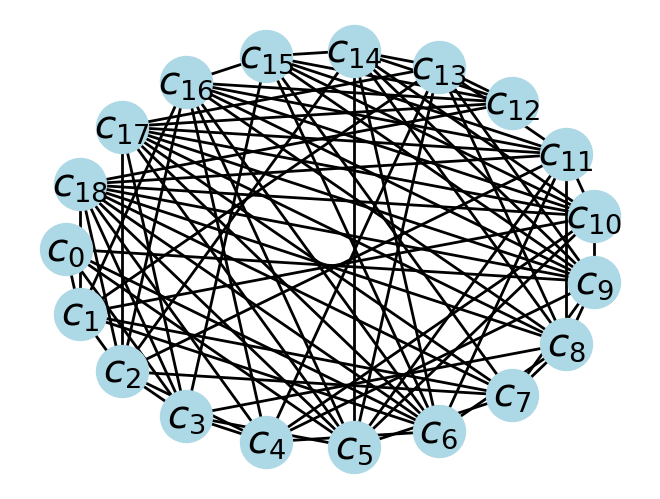

In [7]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = 'xmen_clauses')

In [8]:
clauses_combination = Graph_condition_combination(graph_clauses)
clauses_combination

[[13, 14, 8, 9], [15, 16, 11, 10], [18, 2, 1, 7], [0, 3, 5], [17, 12], [4, 6]]

## Depth

In [9]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

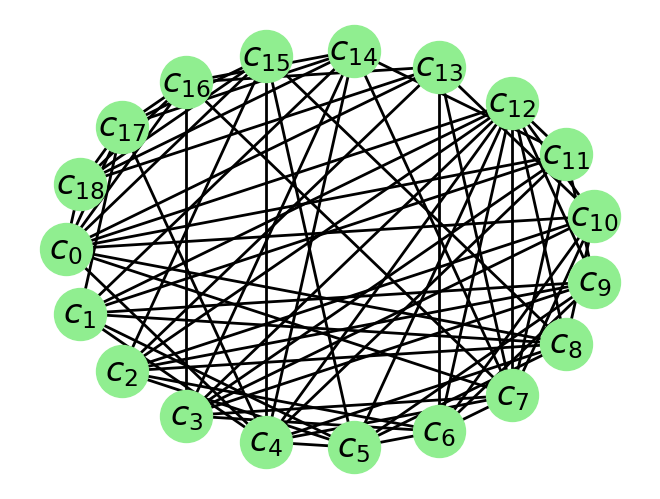

In [10]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

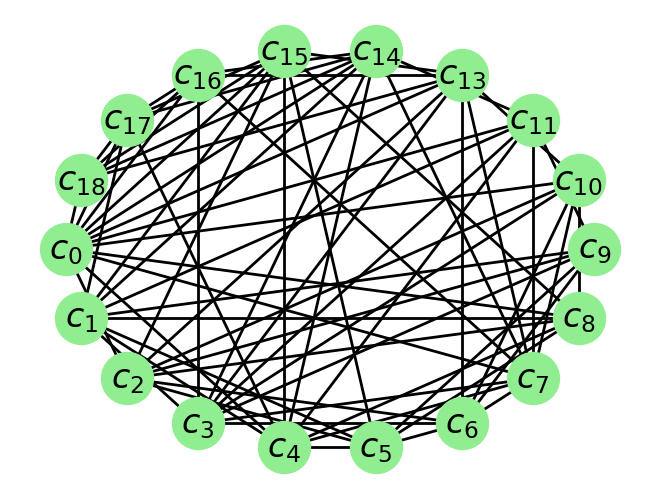

In [11]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

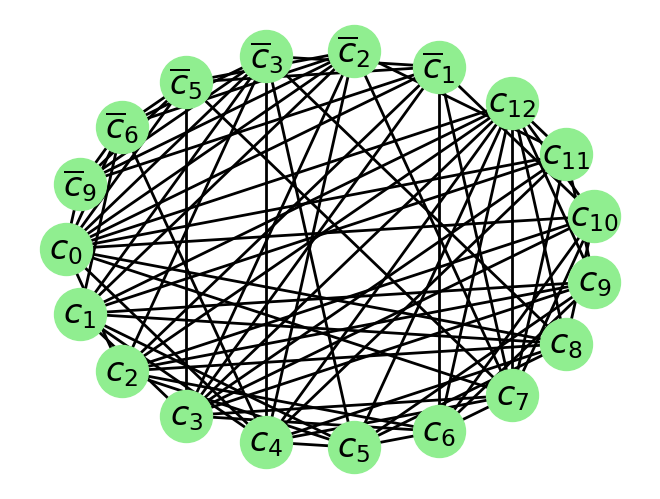

In [12]:
graph_depth7 = graph_depth7(S,c,clauses,num_ext_edges,Set_edges, draw = True,name_graph = '4e16depth7')

In [13]:
depth_combination = Graph_condition_combination(graph_depth)


In [14]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges)


[[0, 4, 13, 11, 7], [1, 5, 8, 14], [12, 2, 10, 6], [15, 16, 17], [9, 3]]


<left><h2> Qubits </h2></left>

In [15]:
# Numbers of qubits to use
num_auxs = len(clauses_combination)

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination)

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [16]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [17]:
circuit3 = circuit_function([[4,14,0,7,11],[3,9],[12],[6,2,13,10],[8,5,15,1],[17,16,18]])

In [18]:
circuit2=circuit_function([[12, 6, 2, 9, 5], [15], [1, 8], [10, 3], [11, 7, 4, 0], [13], [18, 14, 17, 16]])

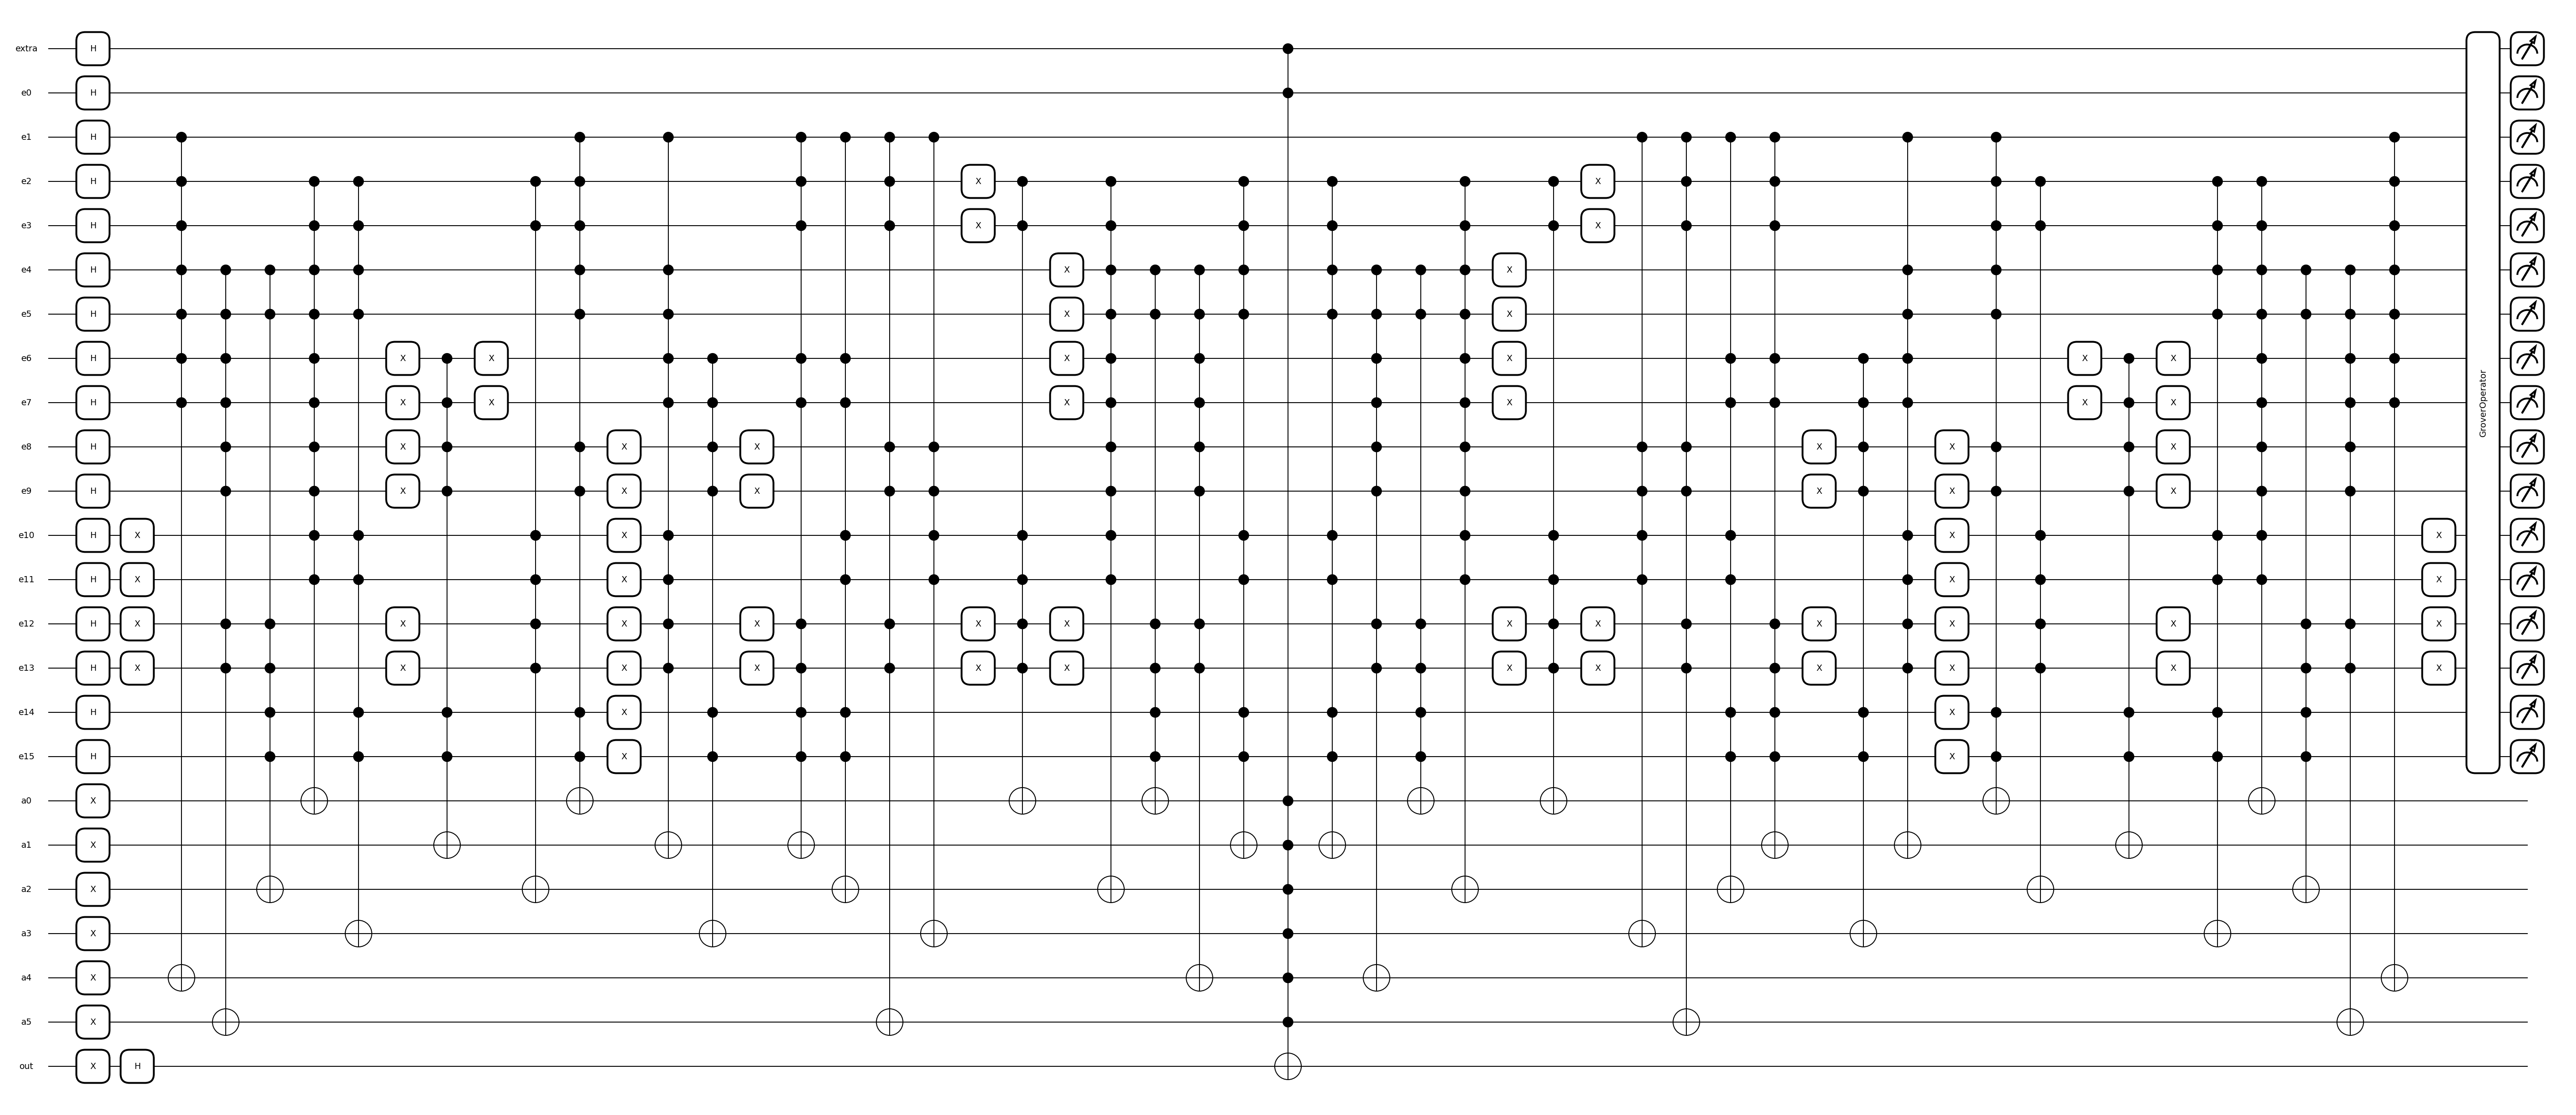

In [19]:
Draw_circuit(circuit2, wire_order_list= total_wires, name_file = name_diagram)

In [20]:
get_depth(circuit2)

The numer of depth of is: 39


In [21]:
num_shots = 3000000

cut = 40

In [ ]:
num_casual_states(circuit2(), cut = 50)

# Prueba con OPTUNA

In [ ]:
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

import itertools

def generar_todas_combinaciones(subconjuntos):
    # Generar todas las permutaciones internas
    permutaciones_internas = [list(itertools.permutations(sub)) for sub in subconjuntos]

    # Producto cartesiano de las permutaciones internas
    producto_cartesiano = itertools.product(*permutaciones_internas)

    # Generar todas las permutaciones del orden de los subconjuntos
    combinaciones_finales = [
        [list(grupo) for grupo in perm]  # Convertir cada tupla interna a lista
        for combinacion in producto_cartesiano
        for perm in itertools.permutations(combinacion)
    ]

    return combinaciones_finales

# Definir el conjunto
subconjuntos = [[12], [0, 4, 14, 11, 7], [1, 5, 8, 15], [13, 2, 10, 6], [16, 17, 18], [9, 3]]
 # Ejemplo de subconjuntos
combinaciones = generar_todas_combinaciones(subconjuntos)


results = {}
for combinacion in combinaciones: 
    results[f"{combinacion}"] = depth_circuit(combinacion)

mejor_combinacion = min(results, key=results.get)
valor_minimo = results[mejor_combinacion]

print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", valor_minimo)

In [ ]:
results

In [ ]:
len(combinaciones)

In [ ]:
import itertools
import optuna
import math

# Lista de subconjuntos base
subconjuntos_base = [[12],[0, 4, 11, 7],[2, 10, 13, 6],[16, 17, 18, 14],[5, 8, 1],[9, 3],[15]]

# Precomputar permutaciones internas de cada subconjunto (como listas de tuplas)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputar número de permutaciones por subconjunto
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total de combinaciones internas
total_comb_internas = math.prod(num_permutaciones)

# Total de permutaciones de orden de subconjuntos
total_ordenes = math.factorial(len(subconjuntos_base))

# Total de combinaciones posibles (no generamos todas)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodificar índices internos para cada subconjunto
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Construir la combinación final
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Ejecutar la optimización
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # puedes ajustar el número de pruebas

# Mostrar el mejor resultado
mejor_idx = study.best_params["idx"]
mejor_combinacion = decodificar_combinacion(mejor_idx)
print("Mejor combinación:", mejor_combinacion)
print("Valor mínimo:", study.best_value)
